# CardioIA — Classificação de Risco Clínico com Machine Learning


Este notebook apresenta a etapa de Machine Learning do projeto CardioIA - Fase 2. O objetivo é desenvolver um classificador capaz de identificar se uma frase descrevendo sintomas de um paciente representa **alto risco** ou **baixo risco**.

## Objetivo
Aplicar técnicas de **Processamento de Linguagem Natural (NLP)** e **Machine Learning** para transformar frases em dados numéricos, treinar diferentes modelos de classificação e comparar seus desempenhos para selecionar a melhor abordagem para o projeto.



## Metodologia

A construção do classificador será realizada nas seguintes etapas:

1. Leitura e inspeção do dataset
2. Análise inicial da base de dados
3. Separação entre variáveis de entrada e saída
4. Vetorização textual com TF-IDF
5. Divisão entre treino e teste
6. Treinamento de 4 modelos de classificação
7. Avaliação comparativa com métricas de desempenho
8. Escolha do melhor modelo e teste com nova frase

Os modelos avaliados serão:

- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM
- Random Forest

Essa abordagem permite comparar diferentes estratégias de classificação textual e selecionar o modelo mais adequado para o problema proposto.

In [31]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
df = pd.read_csv('/content/dataset_risco.csv')
df.head()

,frase,situacao
0,sinto dor no peito e falta de ar há algumas horas,alto risco
1,tenho um leve incômodo nas costas após carrega...,baixo risco
2,sinto aperto no tórax e suor frio desde esta m...,alto risco
3,estou com cansaço leve após uma semana de trab...,baixo risco
4,sinto dor irradiando do peito para o braço esq...,alto risco


## Análise inicial do dataset

Antes de treinar os modelos, é importante verificar a estrutura da base de dados, observar a quantidade de registros, identificar o nome das colunas e analisar a distribuição das classes.

Essa etapa é relevante porque permite entender melhor a base utilizada no experimento e evita treinar modelos sem conhecimento prévio dos dados.

In [33]:
print("Dimensões do dataset:", df.shape)
print("\nColunas:")
print(df.columns)
print("\nValores nulos por coluna:")
print(df.isnull().sum())

Dimensões do dataset: (20, 2)

Colunas:
Index(['frase', 'situacao'], dtype='object')

Valores nulos por coluna:
frase       0
situacao    0
dtype: int64


In [34]:
df['situacao'].value_counts()

,count
situacao,
alto risco,11
baixo risco,9


## Preparação das variáveis

Nesta etapa, a coluna textual será utilizada como variável de entrada (**X**) e a coluna com a classificação da situação clínica será utilizada como variável de saída (**y**).

- **X**: frases com sintomas
- **y**: situação clínica

In [35]:
X = df['frase']
y = df['situacao']

print("Exemplo de frase:")
print(X.iloc[0])

print("\nClasse correspondente:")
print(y.iloc[0])

Exemplo de frase:
sinto dor no peito e falta de ar há algumas horas

Classe correspondente:
alto risco


## Divisão entre treino e teste

A base será dividida em dados de treino e dados de teste.

O conjunto de treino será usado para ensinar os modelos, enquanto o conjunto de teste será utilizado para avaliar seu desempenho em dados não vistos anteriormente.

Essa separação é essencial para medir a capacidade de generalização do modelo.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamanho de treino:", len(X_train))
print("Tamanho de teste:", len(X_test))

Tamanho de treino: 16
Tamanho de teste: 4


## Vetorização textual com TF-IDF

Modelos de Machine Learning não interpretam texto diretamente.

Por isso, as frases precisam ser convertidas em representação numérica.

Para isso, foi utilizado o **TF-IDF (Term Frequency-Inverse Document Frequency)**, que atribui pesos às palavras com base em sua frequência e relevância no conjunto de textos.

Além disso, foi configurado o uso de unigramas e bigramas para capturar tanto palavras isoladas quanto combinações de duas palavras, o que pode melhorar a interpretação de expressões clínicas.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensão da matriz de treino:", X_train_tfidf.shape)
print("Dimensão da matriz de teste:", X_test_tfidf.shape)

Dimensão da matriz de treino: (16, 187)
Dimensão da matriz de teste: (4, 187)


## Modelos avaliados

Foram selecionados quatro modelos de classificação para comparação:

- **Logistic Regression**: modelo linear amplamente utilizado em classificação
- **Multinomial Naive Bayes**: muito eficiente para classificação de textos
- **Linear SVM**: modelo forte para problemas de classificação textual
- **Random Forest**: modelo baseado em múltiplas árvores de decisão

A comparação entre esses algoritmos permite identificar qual apresenta melhor desempenho para o contexto do projeto.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

## Treinamento e avaliação dos modelos

Os modelos serão treinados com o conjunto de treino e avaliados com o conjunto de teste.

As métricas analisadas serão:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

Essas métricas permitem uma análise mais completa do desempenho, especialmente em um problema relacionado à classificação de situação clínica.

In [39]:
from sklearn.metrics import accuracy_score, classification_report

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    y_pred = modelo.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    resultados.append({
        "Modelo": nome,
        "Acurácia": acc,
        "Precision Macro": report["macro avg"]["precision"],
        "Recall Macro": report["macro avg"]["recall"],
        "F1-score Macro": report["macro avg"]["f1-score"]
    })

    print(f"\n{'='*60}")
    print(f"Modelo: {nome}")
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_test, y_pred))


Modelo: Logistic Regression
Acurácia: 0.7500
              precision    recall  f1-score   support

  alto risco       0.67      1.00      0.80         2
 baixo risco       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4


Modelo: Naive Bayes
Acurácia: 0.7500
              precision    recall  f1-score   support

  alto risco       0.67      1.00      0.80         2
 baixo risco       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4


Modelo: Linear SVM
Acurácia: 1.0000
              precision    recall  f1-score   support

  alto risco       1.00      1.00      1.00         2
 baixo risco       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macr

## Comparação final dos modelos

Após o treinamento, os modelos serão comparados em uma tabela consolidada, permitindo identificar qual apresentou o melhor equilíbrio entre as métricas avaliadas.

A ordenação será feita pelo **F1-score Macro**, por ser uma métrica mais equilibrada para comparação entre classificadores.

In [40]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="F1-score Macro", ascending=False)
df_resultados

,Modelo,Acurácia,Precision Macro,Recall Macro,F1-score Macro
2,Linear SVM,1.00,1.000000,1.00,1.000000
0,Logistic Regression,0.75,0.833333,0.75,0.733333
1,Naive Bayes,0.75,0.833333,0.75,0.733333
3,Random Forest,0.75,0.833333,0.75,0.733333


## Seleção do melhor modelo

Com base nos resultados obtidos, será selecionado o modelo com melhor desempenho geral para utilização no projeto.

In [41]:
melhor_modelo_nome = df_resultados.iloc[0]["Modelo"]
print("Melhor modelo selecionado:", melhor_modelo_nome)

Melhor modelo selecionado: Linear SVM


In [42]:
melhor_modelo = modelos[melhor_modelo_nome]

## Matriz de confusão do melhor modelo

Após selecionar o modelo com melhor desempenho, será analisada sua matriz de confusão.

Essa visualização ajuda a entender quantas classificações foram feitas corretamente e em quais casos ocorreram erros.

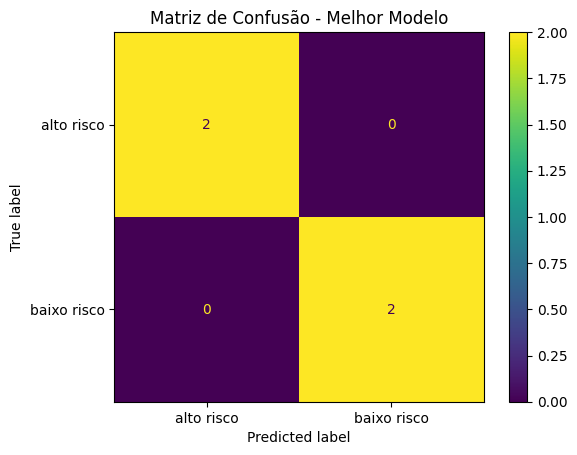

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(melhor_modelo, X_test_tfidf, y_test)
plt.title("Matriz de Confusão - Melhor Modelo")
plt.show()

## Teste prático com nova frase

Para demonstrar a aplicação do classificador, será realizada uma previsão com uma nova frase simulando sintomas de um paciente.

In [44]:
nova_frase = ["dor intensa no peito e falta de ar"]

nova_frase_tfidf = vectorizer.transform(nova_frase)
predicao = melhor_modelo.predict(nova_frase_tfidf)

print("Frase analisada:", nova_frase[0])
print("Classificação prevista:", predicao[0])

Frase analisada: dor intensa no peito e falta de ar
Classificação prevista: alto risco


In [45]:
novas_frases = [
    "dor intensa no peito e falta de ar",
    "cansaco leve e tontura ocasional",
    "palpitacao e suor frio repentino"
]

novas_frases_tfidf = vectorizer.transform(novas_frases)
predicoes = melhor_modelo.predict(novas_frases_tfidf)

for frase, pred in zip(novas_frases, predicoes):
    print(f"Frase: {frase}")
    print(f"Classificação prevista: {pred}\n")

Frase: dor intensa no peito e falta de ar
Classificação prevista: alto risco

Frase: cansaco leve e tontura ocasional
Classificação prevista: baixo risco

Frase: palpitacao e suor frio repentino
Classificação prevista: alto risco



## Conclusão

Neste notebook, foi desenvolvido um classificador de risco clínico a partir de descrições textuais de sintomas de pacientes, utilizando técnicas de Processamento de Linguagem Natural (NLP) e Machine Learning.

A abordagem adotada consistiu na vetorização textual por meio do método TF-IDF, incluindo unigramas e bigramas, permitindo capturar tanto palavras isoladas quanto combinações relevantes de termos clínicos. Essa representação possibilitou transformar dados textuais em formato numérico, viabilizando a aplicação de algoritmos de classificação supervisionada.

Foram avaliados quatro modelos de Machine Learning: Logistic Regression, Multinomial Naive Bayes, Linear SVM e Random Forest. A comparação entre os modelos foi realizada com base em múltiplas métricas de desempenho, incluindo Accuracy, Precision, Recall e F1-score (macro), garantindo uma análise mais equilibrada e confiável dos resultados.

Dentre os modelos testados, o Linear SVM apresentou o melhor desempenho geral, destacando-se principalmente no F1-score, métrica que equilibra precisão e recall. Esse resultado é consistente com a literatura, uma vez que modelos baseados em SVM tendem a performar melhor em tarefas de classificação de texto com alta dimensionalidade, como é o caso da representação TF-IDF.

A análise da matriz de confusão evidenciou boa capacidade do modelo em distinguir entre classes de alto risco e baixo risco, com baixa incidência de erros de classificação. Além disso, testes práticos com novas frases demonstraram a aplicabilidade do modelo em cenários simulados, reforçando seu potencial de uso em sistemas de triagem automatizada.

Entretanto, é importante destacar algumas limitações deste experimento. O conjunto de dados utilizado é relativamente pequeno, o que pode impactar a capacidade de generalização do modelo e favorecer overfitting. Além disso, a abordagem baseada em TF-IDF não considera aspectos mais profundos do contexto semântico das frases, o que poderia ser melhor explorado com técnicas mais avançadas, como embeddings ou modelos baseados em redes neurais.

Como possíveis evoluções futuras, recomenda-se a utilização de bases de dados maiores e mais representativas, além da experimentação com modelos mais sofisticados, como redes neurais ou modelos pré-treinados de linguagem (por exemplo, BERT). Também seria interessante incorporar técnicas de balanceamento de classes e validação cruzada para aumentar a robustez dos resultados.

Em síntese, o projeto demonstrou que técnicas de NLP combinadas com algoritmos clássicos de Machine Learning podem ser eficazes na classificação de risco clínico a partir de texto, servindo como base para aplicações mais complexas na área da saúde.